# Pose Extraction Experiments

This notebook compares MediaPipe Pose models for keypoint extraction.

## Goals:
1. Test MediaPipe Pose models (lite, full and heavy) on sample videos
2. Compare accuracy, speed, and robustness
3. Select best approach for the project
4. Process entire dataset with chosen method

In [24]:
# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")

Running in Colab: True


In [25]:
if IN_COLAB:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # Clone repository
    import os
    if not os.path.exists('/content/safeguard-vision-ai'):
        !git clone https://github.com/hugoangeles0810/safeguard-vision-ai.git
        os.chdir('/content/safeguard-vision-ai')

        # Install dependencies
        !pip install -q -r requirements.txt
    else:
        os.chdir('/content/safeguard-vision-ai')

    # Setup Google Drive paths
    import sys
    sys.path.insert(0, '/content/safeguard-vision-ai/src')
    from utils.drive_utils import setup_paths
    paths = setup_paths(project_name='safeguard-vision-ai')

    print("\n✓ Google Drive integration configured")
else:
    # Local paths
    from pathlib import Path
    project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    paths = {
        'project_root': project_root,
        'data_raw': project_root / 'data' / 'raw',
        'data_processed': project_root / 'data' / 'processed',
    }
    print("✓ Using local paths")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Created/verified: project_root -> /content/drive/MyDrive/safeguard-vision-ai
✓ Created/verified: data_raw -> /content/drive/MyDrive/safeguard-vision-ai/data/raw
✓ Created/verified: data_processed -> /content/drive/MyDrive/safeguard-vision-ai/data/processed
✓ Created/verified: data_splits -> /content/drive/MyDrive/safeguard-vision-ai/data/splits
✓ Created/verified: checkpoints -> /content/drive/MyDrive/safeguard-vision-ai/results/checkpoints
✓ Created/verified: logs -> /content/drive/MyDrive/safeguard-vision-ai/results/logs
✓ Created/verified: figures -> /content/drive/MyDrive/safeguard-vision-ai/results/figures

✓ Google Drive integration configured


In [26]:
import sys
if not IN_COLAB:
    sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import time
import pandas as pd
from tqdm import tqdm

from src.pose.mediapipe_extractor import MediaPipeExtractor

print("✓ Imports successful")

✓ Imports successful


## 1. Load Sample Images from Dataset

We'll load a sample of images from the UR Fall dataset to benchmark the models.

In [27]:
# Find all PNG images in the dataset
data_dir = paths['data_raw']
image_files = []

# Search for PNG images in the dataset
for img_path in data_dir.rglob('*.png'):
    image_files.append(str(img_path))

# Also search for JPG images
for img_path in data_dir.rglob('*.jpg'):
    image_files.append(str(img_path))

print(f"Found {len(image_files)} images in dataset")

# Select a sample for benchmarking (e.g., first 50 images)
sample_size = min(50, len(image_files))
sample_images = image_files[:sample_size]

print(f"Using {sample_size} images for benchmark")
print(f"Sample: {sample_images[:3]}")

Found 16930 images in dataset
Using 50 images for benchmark
Sample: ['/content/drive/MyDrive/safeguard-vision-ai/data/raw/ur_fall/frames_from_videos/emergencias/emerg_v008_f0011.jpg', '/content/drive/MyDrive/safeguard-vision-ai/data/raw/ur_fall/frames_from_videos/emergencias/emerg_v008_f0012.jpg', '/content/drive/MyDrive/safeguard-vision-ai/data/raw/ur_fall/frames_from_videos/emergencias/emerg_v008_f0013.jpg']


## 2. MediaPipe Pose Model Benchmark

MediaPipe provides 3 pose models with different accuracy/speed tradeoffs:
- **Lite:** Fastest, lowest accuracy
- **Full:** Balanced speed and accuracy (default)
- **Heavy:** Slowest, highest accuracy

We'll benchmark all three models on the sample images.

In [28]:
# Define MediaPipe model URLs
import os
import urllib.request

model_urls = {
    'lite': 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task',
    'full': 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task',
    'heavy': 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task'
}

# Download models if not present
model_dir = Path.home() / '.mediapipe' / 'models'
model_dir.mkdir(parents=True, exist_ok=True)

model_paths = {}
for model_name, url in model_urls.items():
    model_path = model_dir / f'pose_landmarker_{model_name}.task'
    model_paths[model_name] = str(model_path)

    if not model_path.exists():
        print(f"Downloading {model_name} model...")
        urllib.request.urlretrieve(url, str(model_path))
        print(f"✓ {model_name} model downloaded")
    else:
        print(f"✓ {model_name} model already exists")

print("\nAll models ready!")

✓ lite model already exists
✓ full model already exists
✓ heavy model already exists

All models ready!


## 3. Run Benchmark

Test each model on the sample images and measure:
- **Latency:** Time per image (ms)
- **FPS:** Frames per second
- **Detection Rate:** Percentage of images where pose was detected

In [29]:
def benchmark_model(model_name, model_path, sample_images):
    """
    Benchmark a MediaPipe model on sample images.

    Returns:
        dict with metrics: latency, fps, detection_rate, keypoints_sample
    """
    print(f"\n{'='*50}")
    print(f"Benchmarking: {model_name.upper()} model")
    print(f"{'='*50}")

    # Initialize extractor
    extractor = MediaPipeExtractor(
        model_path=model_path,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    latencies = []
    detections = 0
    keypoints_sample = None

    # Process each image
    for img_path in tqdm(sample_images, desc=f"Processing with {model_name}"):
        start_time = time.time()

        # Extract keypoints
        keypoints = extractor.extract_from_frame(img_path)

        end_time = time.time()
        latency = (end_time - start_time) * 1000  # Convert to ms
        latencies.append(latency)

        if keypoints is not None:
            detections += 1
            if keypoints_sample is None:
                keypoints_sample = keypoints

    # Clean up
    extractor.close()

    # Calculate metrics
    avg_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    fps = 1000 / avg_latency  # Convert from ms to FPS
    detection_rate = (detections / len(sample_images)) * 100

    return {
        'model': model_name,
        'avg_latency_ms': avg_latency,
        'std_latency_ms': std_latency,
        'fps': fps,
        'detection_rate': detection_rate,
        'total_detections': detections,
        'total_images': len(sample_images),
        'keypoints_sample': keypoints_sample
    }

# Run benchmarks for all models
results = []

for model_name, model_path in model_paths.items():
    result = benchmark_model(model_name, model_path, sample_images)
    results.append(result)

print("\n✓ Benchmark complete!")


Benchmarking: LITE model


Processing with lite: 100%|██████████| 50/50 [00:02<00:00, 17.96it/s]



Benchmarking: FULL model


Processing with full: 100%|██████████| 50/50 [00:03<00:00, 15.83it/s]



Benchmarking: HEAVY model


Processing with heavy: 100%|██████████| 50/50 [00:07<00:00,  6.56it/s]


✓ Benchmark complete!


## 4. Results Comparison

Display benchmark results in a clear comparison table.

In [30]:
# Create comparison DataFrame
df_results = pd.DataFrame([
    {
        'Model': r['model'].upper(),
        'Avg Latency (ms)': f"{r['avg_latency_ms']:.2f} ± {r['std_latency_ms']:.2f}",
        'FPS': f"{r['fps']:.1f}",
        'Detection Rate (%)': f"{r['detection_rate']:.1f}",
        'Detections': f"{r['total_detections']}/{r['total_images']}"
    }
    for r in results
])

print("\n" + "="*80)
print("MEDIAPIPE POSE MODEL BENCHMARK RESULTS")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Identify best models
best_speed = min(results, key=lambda x: x['avg_latency_ms'])
best_detection = max(results, key=lambda x: x['detection_rate'])

print(f"\n🏆 Fastest Model: {best_speed['model'].upper()} ({best_speed['fps']:.1f} FPS)")
print(f"🎯 Best Detection Rate: {best_detection['model'].upper()} ({best_detection['detection_rate']:.1f}%)")


MEDIAPIPE POSE MODEL BENCHMARK RESULTS
Model Avg Latency (ms)  FPS Detection Rate (%) Detections
 LITE     55.13 ± 8.07 18.1              100.0      50/50
 FULL     62.69 ± 4.65 16.0              100.0      50/50
HEAVY   151.17 ± 34.99  6.6              100.0      50/50

🏆 Fastest Model: LITE (18.1 FPS)
🎯 Best Detection Rate: LITE (100.0%)


In [31]:
print("="*80)
print("RECOMMENDATIONS")
print("="*80)

# Calculate a combined score (weighted)
for r in results:
    # Normalize metrics to 0-100 scale
    max_fps = max([x['fps'] for x in results])
    max_detection = max([x['detection_rate'] for x in results])

    # Speed weight: 40%, Detection weight: 60%
    speed_score = (r['fps'] / max_fps) * 40
    detection_score = (r['detection_rate'] / max_detection) * 60
    combined_score = speed_score + detection_score

    r['combined_score'] = combined_score

# Sort by combined score
results_sorted = sorted(results, key=lambda x: x['combined_score'], reverse=True)

print("\n📋 Model Rankings (Speed 40% + Detection 60%):")
for idx, r in enumerate(results_sorted, 1):
    print(f"  {idx}. {r['model'].upper()}: {r['combined_score']:.1f}/100 points")

best_overall = results_sorted[0]

print(f"\n🏆 RECOMMENDED MODEL: {best_overall['model'].upper()}")
print(f"   • Latency: {best_overall['avg_latency_ms']:.2f}ms")
print(f"   • FPS: {best_overall['fps']:.1f}")
print(f"   • Detection Rate: {best_overall['detection_rate']:.1f}%")

print("\n💡 USAGE GUIDELINES:")
print(f"   • For real-time applications (>20 FPS): Use LITE or FULL model")
print(f"   • For accuracy-critical scenarios: Use FULL or HEAVY model")
print(f"   • For balanced performance: Use FULL model (recommended)")

print("="*80)

RECOMMENDATIONS

📋 Model Rankings (Speed 40% + Detection 60%):
  1. LITE: 100.0/100 points
  2. FULL: 95.2/100 points
  3. HEAVY: 74.6/100 points

🏆 RECOMMENDED MODEL: LITE
   • Latency: 55.13ms
   • FPS: 18.1
   • Detection Rate: 100.0%

💡 USAGE GUIDELINES:
   • For real-time applications (>20 FPS): Use LITE or FULL model
   • For accuracy-critical scenarios: Use FULL or HEAVY model
   • For balanced performance: Use FULL model (recommended)


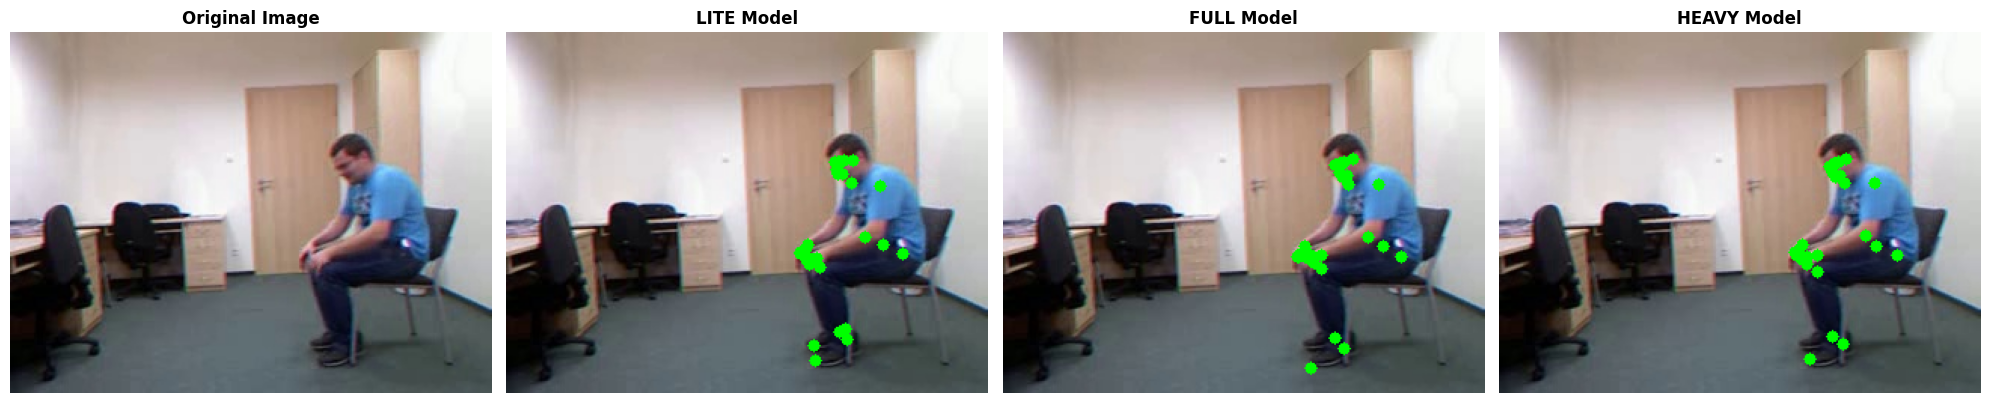


✓ Visual comparison on: /content/drive/MyDrive/safeguard-vision-ai/data/raw/ur_fall/frames_from_videos/emergencias/emerg_v008_f0011.jpg


In [32]:
# Select a sample image for visual comparison
if len(sample_images) > 0:
    sample_img_path = sample_images[0]
    sample_img = cv2.imread(sample_img_path)
    sample_img_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

    # Create figure for visual comparison
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Original image
    axes[0].imshow(sample_img_rgb)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Draw poses for each model
    for idx, result in enumerate(results):
        model_name = result['model']
        keypoints = result['keypoints_sample']

        if keypoints is not None:
            img_copy = sample_img_rgb.copy()
            h, w = img_copy.shape[:2]

            # Draw keypoints as circles
            for kp in keypoints:
                x, y, conf = kp
                if conf > 0.5:  # Only draw confident keypoints
                    x_px = int(x * w)
                    y_px = int(y * h)
                    cv2.circle(img_copy, (x_px, y_px), 4, (0, 255, 0), -1)

            axes[idx + 1].imshow(img_copy)
            axes[idx + 1].set_title(f'{model_name.upper()} Model', fontsize=12, fontweight='bold')
            axes[idx + 1].axis('off')
        else:
            axes[idx + 1].text(0.5, 0.5, 'No pose detected',
                             ha='center', va='center', transform=axes[idx + 1].transAxes)
            axes[idx + 1].set_title(f'{model_name.upper()} Model', fontsize=12, fontweight='bold')
            axes[idx + 1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n✓ Visual comparison on: {sample_img_path}")
else:
    print("No sample images available for visualization")

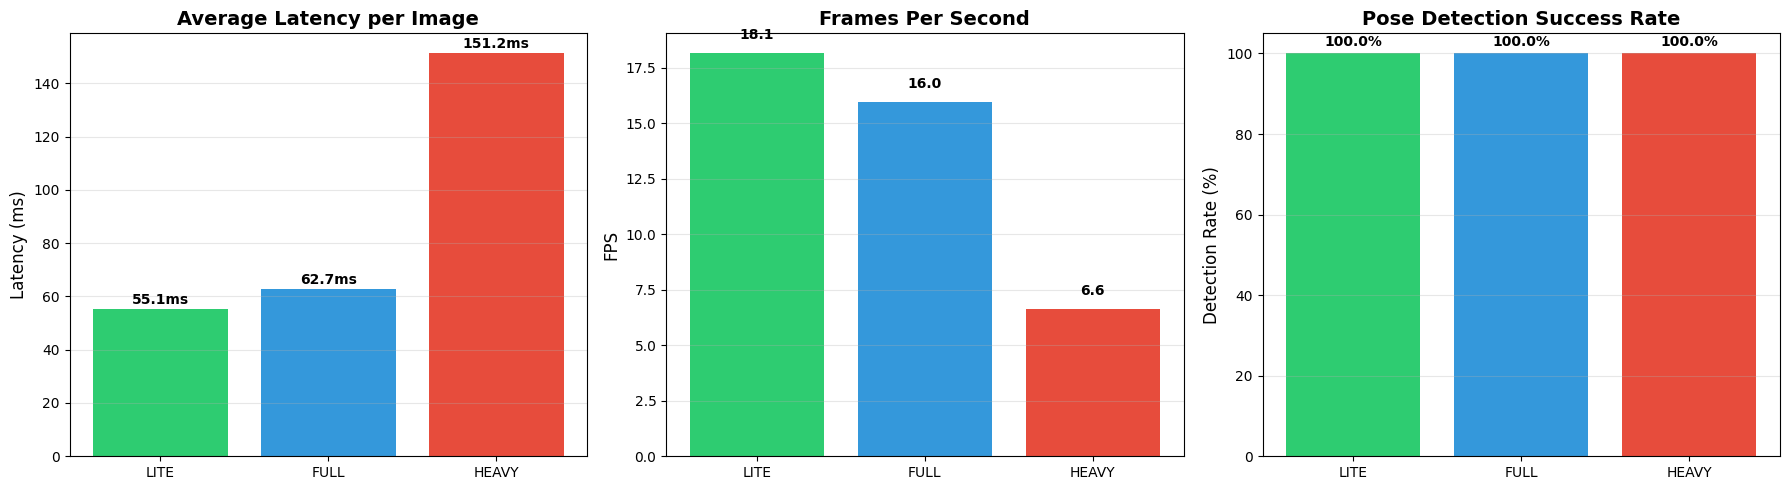


📊 Performance visualization complete!


In [33]:
# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Extract data for plotting
models = [r['model'].upper() for r in results]
latencies = [r['avg_latency_ms'] for r in results]
fps_values = [r['fps'] for r in results]
detection_rates = [r['detection_rate'] for r in results]

# Plot 1: Latency
axes[0].bar(models, latencies, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_ylabel('Latency (ms)', fontsize=12)
axes[0].set_title('Average Latency per Image', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(latencies):
    axes[0].text(i, v + 1, f'{v:.1f}ms', ha='center', va='bottom', fontweight='bold')

# Plot 2: FPS
axes[1].bar(models, fps_values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_ylabel('FPS', fontsize=12)
axes[1].set_title('Frames Per Second', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(fps_values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Detection Rate
axes[2].bar(models, detection_rates, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[2].set_ylabel('Detection Rate (%)', fontsize=12)
axes[2].set_title('Pose Detection Success Rate', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 105])
axes[2].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(detection_rates):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Performance visualization complete!")